In [6]:
# Customer Segmentation and Insight Generation

## Objective
#Segment customers based on demographic, purchasing, and campaign response behavior using PCA and K-Means clustering to generate actionable business insights.

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [8]:
df = pd.read_csv("../data/marketing_campaign.csv", sep="\t")

In [9]:
print("Shape:", df.shape)
df.head()

Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [10]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [11]:
(df.isnull().sum() / len(df)) * 100

ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Complain               0.000000
Z_CostContact          0.000000
Z_Revenue              0.000000
Response               0.000000
dtype: float64

In [12]:
df["Income"] = df["Income"].fillna(df["Income"].median())
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [13]:
df.shape

(2240, 29)

In [14]:
df["Age"] = 2026 - df["Year_Birth"]
df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]


In [15]:
df["TotalSpending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)


In [16]:
df["TotalPurchases"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

In [17]:
df["CampaignAcceptanceCount"] = (
    df["AcceptedCmp1"]
    + df["AcceptedCmp2"]
    + df["AcceptedCmp3"]
    + df["AcceptedCmp4"]
    + df["AcceptedCmp5"]
)

In [18]:
df["AverageSpendPerPurchase"] = (
    df["TotalSpending"] /
    (df["TotalPurchases"] + 1)
)

In [19]:
df["OnlinePurchaseRatio"] = (
    df["NumWebPurchases"] /
    (df["TotalPurchases"] + 1)
)

In [20]:
df["Dt_Customer"].head()
#checked the data type of Dt_Customer column and converted it to datetime format

0    04-09-2012
1    08-03-2014
2    21-08-2013
3    10-02-2014
4    19-01-2014
Name: Dt_Customer, dtype: str

In [21]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y"
)
df["CustomerTenure"] = (
    pd.Timestamp.today() - df["Dt_Customer"]
).dt.days

In [22]:
df[["Dt_Customer", "CustomerTenure"]].head()

,Dt_Customer,CustomerTenure
0,2012-09-04,5037
1,2014-03-08,4487
2,2013-08-21,4686
3,2014-02-10,4513
4,2014-01-19,4535


In [23]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'TotalChildren', 'TotalSpending', 'TotalPurchases',
       'CampaignAcceptanceCount', 'AverageSpendPerPurchase',
       'OnlinePurchaseRatio', 'CustomerTenure'],
      dtype='str')

In [24]:
print(df["Education"].unique())
print(df["Marital_Status"].unique())

<ArrowStringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str
<ArrowStringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str


In [25]:
df_encoded = pd.get_dummies(
    df,
    columns=["Education", "Marital_Status"],
    drop_first=True
)

In [26]:
df_encoded.shape

(2240, 46)

In [27]:
df_encoded = df_encoded.drop(columns=["Dt_Customer"])
df_encoded.shape

(2240, 45)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_encoded)
#feature scaling is important for PCA and K-Means clustering to ensure that all features contribute equally to the analysis.

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)
#PCA is used to reduce the dimensionality 

In [30]:
pca_data.shape

(2240, 2)

In [31]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.21921255 0.07080846]
0.2900210055518371


In [32]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,4.559252,0.347703
1,-3.126303,0.288767
2,1.888382,0.251257
3,-2.993549,-1.916471
4,-0.658784,-0.208367


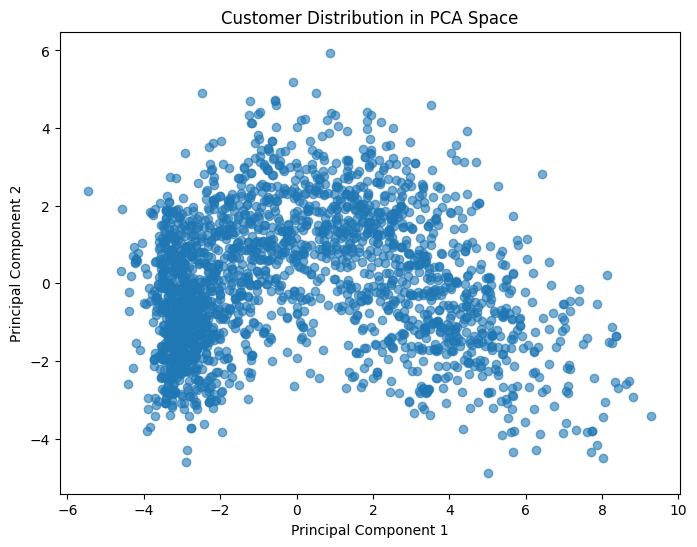

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Distribution in PCA Space")

plt.show()
#PCA Visualization shows how customers are distributed in the reduced feature space, which can help identify potential clusters or patterns in customer behavior.

In [34]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

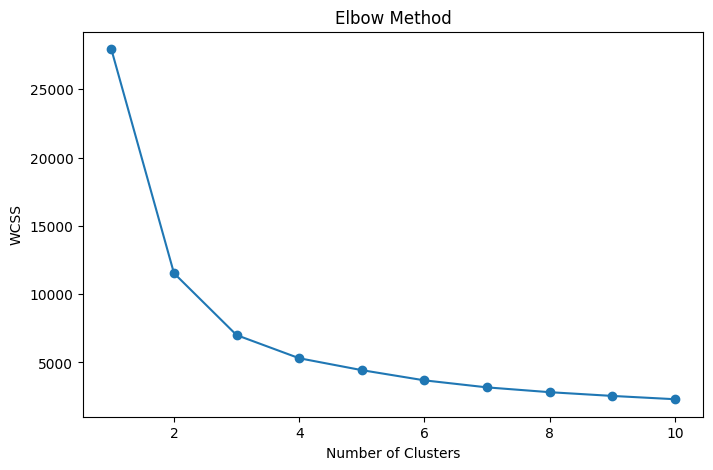

In [35]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [36]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(pca_data)

pca_df["Cluster"] = clusters

In [37]:
pca_df["Cluster"].value_counts()

Cluster
3    718
0    547
1    533
2    442
Name: count, dtype: int64

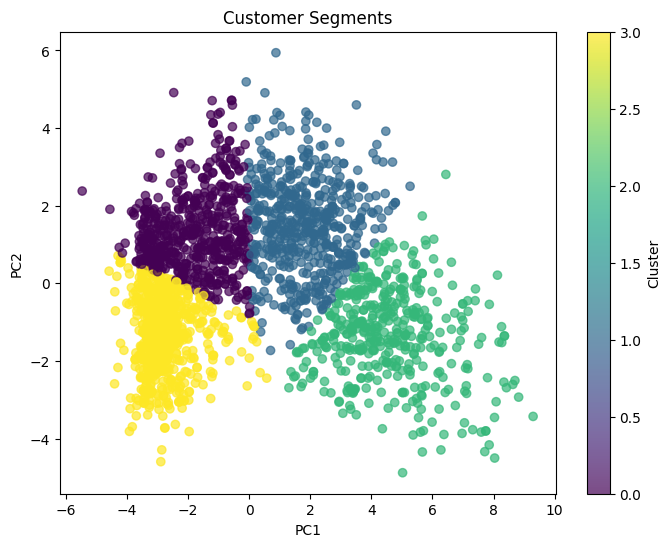

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments")
plt.colorbar(label="Cluster")

plt.show()
#visualize clusters 

In [39]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    pca_data,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.41571586862649834


In [40]:
df_encoded["Cluster"] = clusters
cluster_summary = df_encoded.groupby("Cluster").mean()

cluster_summary
#analyse cluster characteristics to understand the differences between customer segments and generate actionable insights for marketing strategies.

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
Cluster,,,,,,,,,,,,,,,,,,,,,
0,5570.107861,1962.813528,45445.268739,0.617916,0.943327,50.376600,150.340037,7.499086,51.374771,11.107861,...,0.464351,0.223035,0.259598,0.001828,0.118830,0.387569,0.153565,0.292505,0.042048,0.003656
1,5455.050657,1963.392120,64929.084428,0.114447,0.804878,49.054409,539.799250,39.330206,203.174484,53.174484,...,0.480300,0.150094,0.287054,0.000000,0.136961,0.392120,0.150094,0.264540,0.056285,0.000000
2,5671.165158,1970.604072,77686.079186,0.031674,0.056561,49.626697,659.769231,67.932127,504.199095,99.665158,...,0.561086,0.147059,0.203620,0.000000,0.085973,0.348416,0.282805,0.242081,0.036199,0.000000
3,5662.105850,1976.282730,32325.980501,0.810585,0.228412,47.866295,26.809192,5.328691,20.498607,7.781337,...,0.513928,0.143454,0.140669,0.002786,0.077994,0.402507,0.266017,0.239554,0.011142,0.000000


In [41]:
cluster_summary = df_encoded.groupby("Cluster")[[
    "Income",
    "TotalSpending",
    "TotalPurchases",
    "NumWebVisitsMonth",
    "CampaignAcceptanceCount",
    "Recency",
    "Age"
]].mean()

cluster_summary

,Income,TotalSpending,TotalPurchases,NumWebVisitsMonth,CampaignAcceptanceCount,Recency,Age
Cluster,,,,,,,
0,45445.268739,256.416819,9.753199,6.274223,0.091408,50.376600,63.186472
1,64929.084428,946.409006,19.322702,4.930582,0.264540,49.054409,62.607880
2,77686.079186,1480.490950,19.472851,2.660633,0.938914,49.626697,55.395928
3,32325.980501,80.661560,5.350975,6.508357,0.084958,47.866295,49.717270


Cluster Visualization

In [42]:
cluster_names = {
    0: "Low Engagement",
    1: "Loyal",
    2: "Premium",
    3: "Occasional"
}

pca_df["Segment"] = pca_df["Cluster"].map(cluster_names)

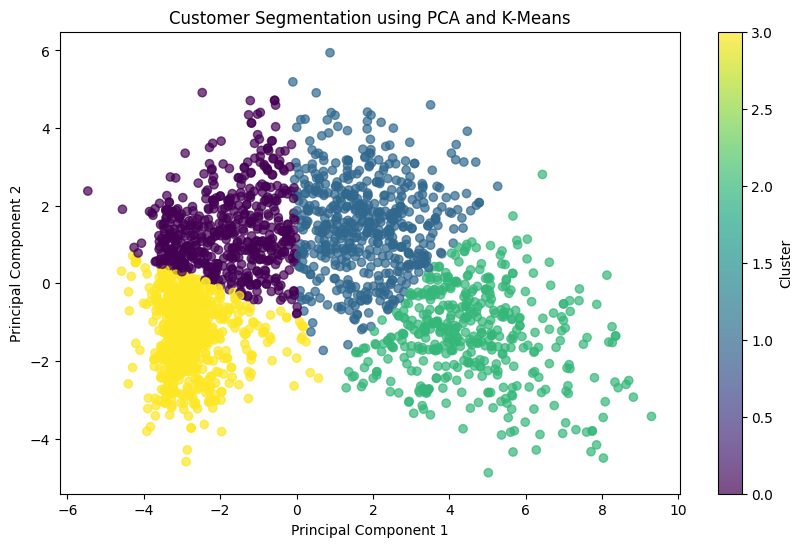

In [43]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using PCA and K-Means")

plt.colorbar(scatter,label="Cluster")

plt.show()

# Business Insights

## Cluster 0: Low Engagement Customers
- Lowest income and spending levels.
- Minimal purchase activity.
- Very low campaign response rates.

Recommendation:
- Provide introductory discounts and personalized offers.
- Run retention and awareness campaigns.

---

## Cluster 1: Loyal Customers
- Consistent spending and purchasing behavior.
- Strong customer base with recurring purchases.

Recommendation:
- Implement loyalty rewards programs.
- Offer subscription and membership benefits.

---

## Cluster 2: Premium Customers
- Highest income and spending levels.
- Strong response to marketing campaigns.
- Highest customer value segment.

Recommendation:
- Offer VIP memberships and premium product bundles.
- Provide exclusive early-access promotions.

---

## Cluster 3: Occasional Customers
- Moderate spending and engagement levels.
- Purchase infrequently.

Recommendation:
- Use targeted seasonal promotions.
- Improve engagement through personalized marketing.

# Conclusion

This project developed a customer segmentation framework using demographic, purchasing, and campaign response data.

Key Achievements:
- Processed 2,240+ customer records.
- Engineered 30+ behavioral features.
- Reduced 40+ dimensions into 2 principal components using PCA.
- Identified 4 distinct customer segments using K-Means clustering.
- Generated actionable business strategies for each segment.

The model enables businesses to better understand customer behavior and design targeted marketing strategies for improved customer engagement and revenue growth.

In [44]:
final_df = df.copy()

final_df["Cluster"] = clusters

final_df.to_csv(
    "../outputs/customer_segments.csv",
    index=False
)

print("Customer segments saved successfully!")

Customer segments saved successfully!


In [45]:
pca_df.head()

,PC1,PC2,Cluster,Segment
0,4.559252,0.347703,2,Premium
1,-3.126303,0.288767,3,Occasional
2,1.888382,0.251257,1,Loyal
3,-2.993549,-1.916471,3,Occasional
4,-0.658784,-0.208367,0,Low Engagement


In [46]:
from sklearn.metrics import silhouette_score

score = silhouette_score(pca_data, clusters)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.416


In [47]:
plt.savefig("../assets/pca_plot.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [48]:
plt.savefig("../assets/elbow_method.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [49]:
plt.savefig("../assets/customer_segments.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>